In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("./data/Social_Network_Ads.csv")

In [3]:
df = df.drop(columns = ["User ID", "Gender"])

In [4]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [5]:
X = df.iloc[:, :2]
X

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [6]:
y = df.iloc[:, -1]
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

In [8]:
X_train.shape, y_train.shape

((280, 2), (280,))

In [9]:
# Standardization

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train) #fit on training data, it will first calculate parameters(eg, mean)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
scaler.mean_

array([3.71000000e+01, 6.90571429e+04])

In [11]:
X_train_scaled

array([[-9.79100420e-01, -1.11059025e+00],
       [-2.03575335e-01,  5.66967998e-02],
       [ 1.15359356e+00, -1.19813678e+00],
       [-2.03575335e-01,  6.40340327e-01],
       [-9.69406357e-03,  1.73425505e-01],
       [-4.94397242e-01,  1.39907691e+00],
       [-1.06634699e-01,  1.73425505e-01],
       [-1.65768487e+00,  4.94429445e-01],
       [ 8.72465721e-02, -5.56128904e-01],
       [ 1.15359356e+00, -9.64679373e-01],
       [ 2.81127843e-01, -1.18396258e-01],
       [-9.69406357e-03,  2.31789858e-01],
       [ 2.21994056e+00, -6.72857609e-01],
       [ 1.05665293e+00,  2.01190262e+00],
       [ 2.81127843e-01,  5.66967998e-02],
       [-1.06634699e-01, -1.76760611e-01],
       [-1.07604106e+00,  3.48518563e-01],
       [-3.97456606e-01, -1.11059025e+00],
       [ 3.78068479e-01, -5.26946727e-01],
       [ 8.62771657e-01,  1.44243329e-01],
       [-1.85156614e+00,  3.77700740e-01],
       [-9.69406357e-03, -1.05222590e+00],
       [-2.03575335e-01, -4.68582375e-01],
       [-8.

In [12]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [13]:
X_train_scaled

,Age,EstimatedSalary
0,-0.979100,-1.110590
1,-0.203575,0.056697
2,1.153594,-1.198137
3,-0.203575,0.640340
4,-0.009694,0.173426
...,...,...
275,1.444415,0.611158
276,-1.657685,-1.344048
277,1.347475,-1.344048
278,0.862772,0.290154


In [14]:
X_train_scaled.describe()

,Age,EstimatedSalary
count,2.800000e+02,2.800000e+02
mean,-1.459150e-16,6.344132e-17
std,1.001791e+00,1.001791e+00
min,-1.851566e+00,-1.577505e+00
25%,-7.852191e-01,-7.604041e-01
50%,-9.694064e-03,-6.003191e-02
75%,6.204201e-01,4.652473e-01
max,2.219941e+00,2.362089e+00


In [15]:
np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,-0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.0,-0.1
75%,0.6,0.5
max,2.2,2.4


Effect of scalling on dataset

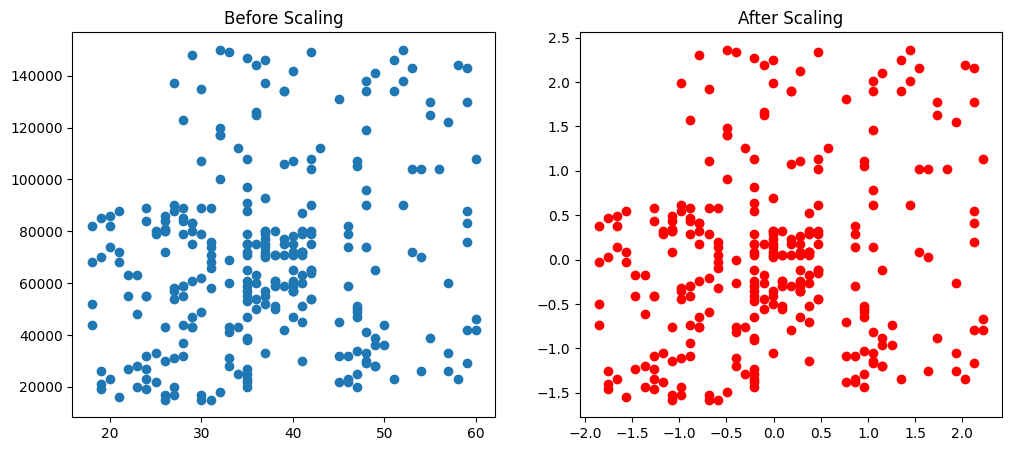

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)  # 1 row, 2 cols, plot 1
plt.scatter(X_train['Age'], X_train['EstimatedSalary'])
plt.title("Before Scaling")

plt.subplot(1, 2, 2)  # 1 row, 2 cols, plot 2
plt.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'], color='red')
plt.title("After Scaling")

plt.show()


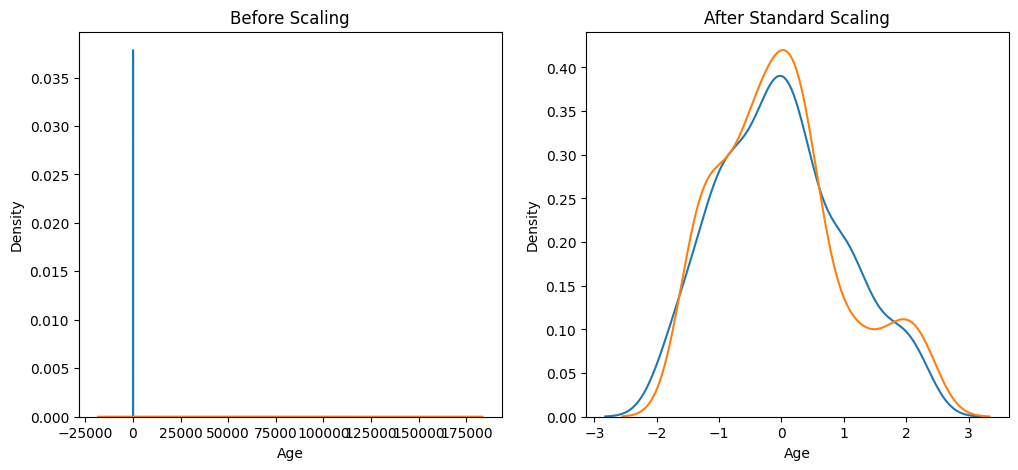

In [17]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title('Before Scaling')
sns.kdeplot(X_train['Age'])
sns.kdeplot(X_train['EstimatedSalary'])

plt.subplot(1, 2, 2)
plt.title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'])
sns.kdeplot(X_train_scaled['EstimatedSalary'])

plt.show()

Comparison of Distributions

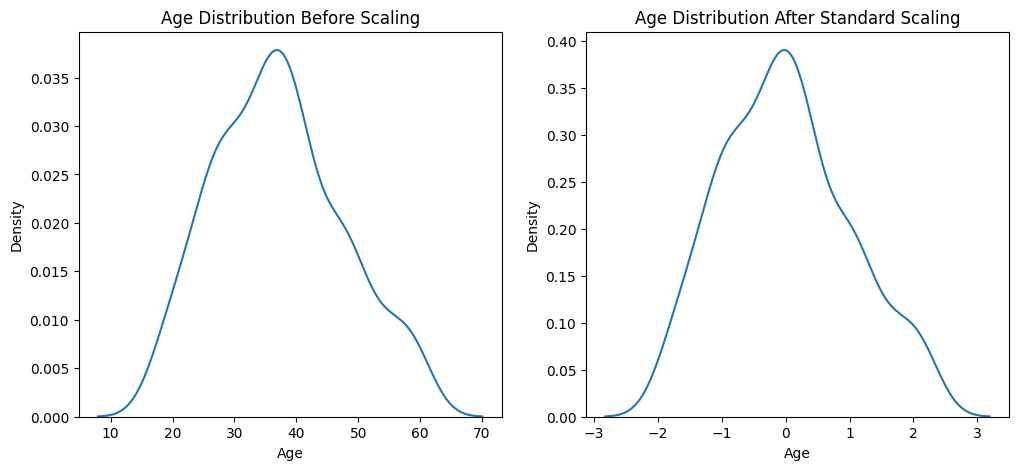

In [18]:
plt.figure(figsize=(12, 5))

# before scaling
plt.subplot(1, 2, 1)
plt.title('Age Distribution Before Scaling')
sns.kdeplot(X_train['Age'])

# after scaling
plt.subplot(1, 2, 2)
plt.title('Age Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'])

plt.show()


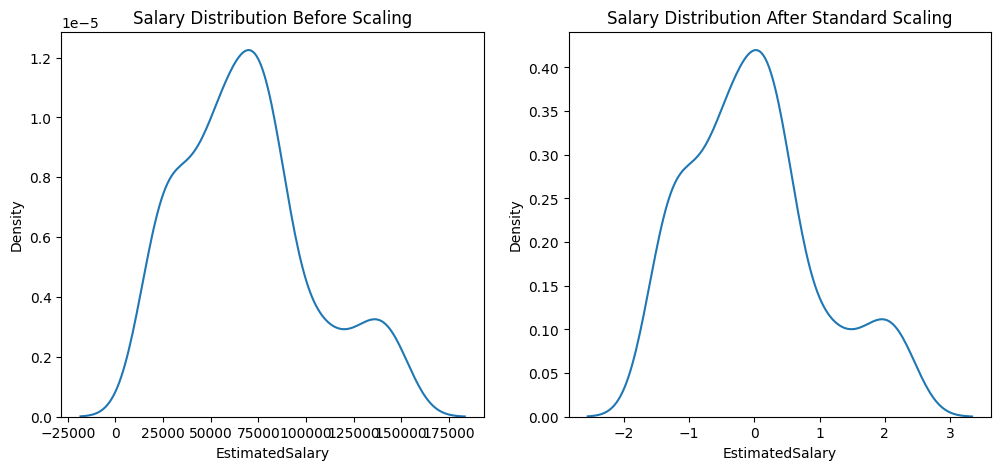

In [19]:
plt.figure(figsize=(12, 5))

# before scaling
plt.subplot(1, 2, 1)
plt.title('Salary Distribution Before Scaling')
sns.kdeplot(X_train['EstimatedSalary'])

# after scaling
plt.subplot(1, 2, 2)
plt.title('Salary Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['EstimatedSalary'])

plt.show()


Effect of Outlier

In [20]:
# New rows to add
new_rows = pd.DataFrame({'Age':[5,90,95],
                         'EstimatedSalary':[1000,250000,350000],
                         'Purchased':[0,1,1]})

# Use pd.concat instead of append
df = pd.concat([df, new_rows], ignore_index=True)

In [21]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


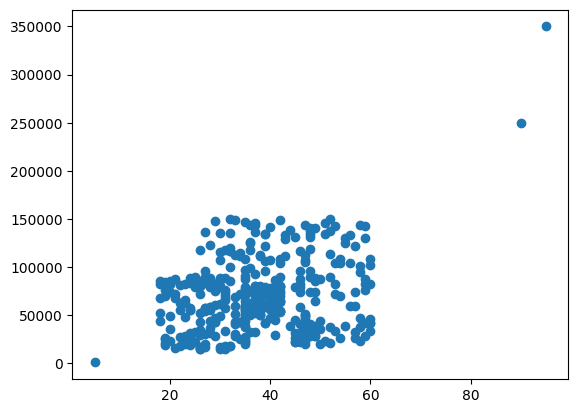

In [22]:
plt.scatter(df['Age'], df['EstimatedSalary'])

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1),
                                                    df['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((282, 2), (121, 2))

In [24]:
# Standardization

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train) #fit on training data, it will first calculate parameters(eg, mean)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

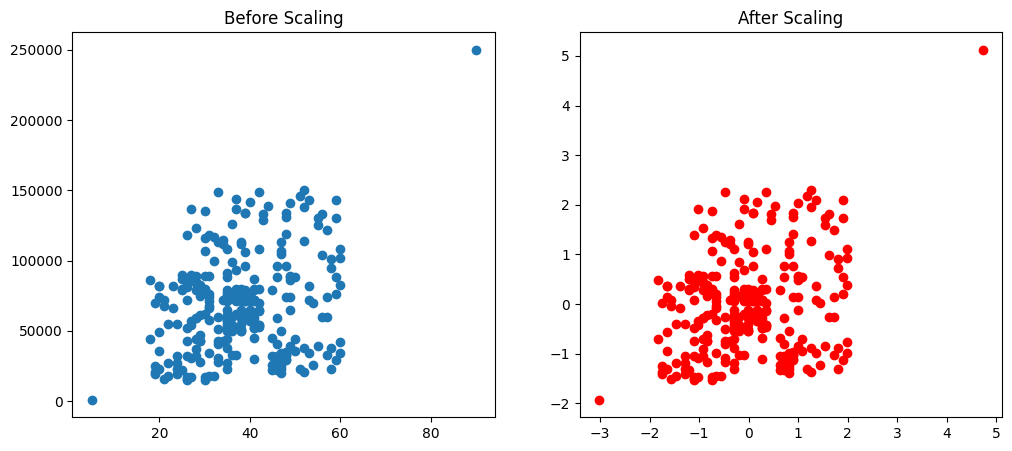

In [26]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)  # 1 row, 2 cols, plot 1
plt.scatter(X_train['Age'], X_train['EstimatedSalary'])
plt.title("Before Scaling")

plt.subplot(1, 2, 2)  # 1 row, 2 cols, plot 2
plt.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'], color='red')
plt.title("After Scaling")

plt.show()
